In [1]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install xformers --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 100.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 59.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 121.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5

In [2]:
!pip install clip-interrogator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 787.8/787.8 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00


### Import Libraries

In [26]:
import torch
import numpy as np
from PIL import Image, ImageOps, ImageDraw, ImageFilter
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from diffusers import UniPCMultistepScheduler
import cv2
import random
from typing import List, Dict, Optional
from PIL import Image
from clip_interrogator import Config, Interrogator
from matplotlib import pyplot as plt
import matplotlib.image as mpimg

### Define Prompt Enhancer

In [37]:
class PromptEnhancer:
    # Custom styles to enhance the prompt
    Styles={
        "realistic":"hyper realistic, 8k, ultra detailed, photographic, intricate details, professional photography",
        "fantasy": "fantasy art, dreamlike, mystical, ethereal, magical, vibrant colors, highly detailed",
        "painting": "oil painting, brush strokes, textured, artistic, gallery quality, masterpiece",
        "cyberpunk": "cyberpunk, neon lights, futuristic, rain-soaked, high tech low life, cinematic lighting",
        "minimalist": "minimalist, clean lines, simple background, elegant, modern art",
        "watercolor": "watercolor painting, soft edges, pastel colors, artistic, delicate",
        "steampunk": "steampunk, brass gears, mechanical, vintage technology, intricate details",
        "anime": "anime style, vibrant colors, clean lines, expressive eyes, studio ghibli, makoto shinkai"
    }

    Qualityboosters= [
        "4k resolution", "8k resolution", "ultra detailed", "intricate details",
        "professional photography", "award winning", "trending on artstation",
        "unreal engine 5", "octane render", "ray tracing"
    ]

    CompostionEnhancers= [
        "dynamic composition", "rule of thirds", "balanced framing",
        "leading lines", "depth of field", "cinematic lighting",
        "dramatic shadows", "volumetric lighting", "atmospheric perspective"
    ]

    @classmethod
    def enhance_prompt(cls,base_prompt:str,style:str = "realistic",quality_boost: bool = True, composition_enhance: bool = True) -> str:
        # Step1: Clean the prompt made by the clip interrogator
        clean_prompt= base_prompt.split(",")[0]

        #Step2: Add styles to it
        style_preset =cls.Styles.get(style.lower(), cls.Styles["realistic"])
        enhanced_prompt= f"{clean_prompt},{style_preset}"

        #Step3: Add quality boosters to it
        if quality_boost:
            boosters =random.sample(cls.Qualityboosters, 2)
            enhanced_prompt +=", " + ", ".join(boosters)

        #Step4: Add composition enhancers to it
        if composition_enhance:
            enhancers =random.sample(cls.CompostionEnhancers, 2)
            enhanced_prompt+= ", " + ", ".join(enhancers)

        return enhanced_prompt


### Define the ControlNet model

In [8]:
class SketchToImageGenerator:
    def __init__(self,base_model="runwayml/stable-diffusion-v1-5", controlnet_model="lllyasviel/control_v11p_sd15_scribble"):
        # Initialize the controlnet model
        self.device= "cuda" if torch.cuda.is_available() else "cpu"
        self.dtype= torch.float16 if self.device == "cuda" else torch.float32
        self.controlnet= ControlNetModel.from_pretrained(controlnet_model,torch_dtype=self.dtype)

        self.pipe= StableDiffusionControlNetPipeline.from_pretrained(base_model,controlnet=self.controlnet,torch_dtype=self.dtype,safety_checker=None,requires_safety_checker=False).to(self.device)

        self.pipe.scheduler= UniPCMultistepScheduler.from_config(self.pipe.scheduler.config)

        if self.device =="cuda":
            self.pipe.enable_xformers_memory_efficient_attention()
            self.pipe.enable_attention_slicing()

        self.conditioning_scale = 1.0
        self.guance_start = 0.0
        self.guance_end = 1.0

    def preprocessSketch(self, sketch_image):
        # Process sketch for better image generation

        #Step1: Convert to grayscale
        if isinstance(sketch_image, str):
            sketch = Image.open(sketch_image).convert("L")
        else:
            sketch = sketch_image.convert("L")

        #Step2: Resize to multiple of 64 for better quality
        width, height = sketch.size
        new_width = (width // 64) * 64
        new_height = (height // 64) * 64
        sketch = sketch.resize((new_width, new_height))

        #Step3:edge enhancement
        sketch_np = np.array(sketch)
        sketch_np = cv2.adaptiveThreshold(
            sketch_np, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, 11, 2
        )

        # Step4: Noise reduction using median filter
        sketch_np = cv2.medianBlur(sketch_np, 3)

        return Image.fromarray(sketch_np)

    def generate(self,sketch_image,prompt,negative_prompt="",num_images=1,steps=30,guidance_scale=7.5,controlnet_conditioning_scale=None,seed=None,style: str = "realistic",enhance_prompt: bool = True):
        #Step1: Preprocess sketch
        processed_sketch = self.preprocessSketch(sketch_image)

        #Step2: Enhance the prompt
        if enhance_prompt:
            prompt = PromptEnhancer.enhance_prompt(prompt, style=style)
            print(f"Enhanced prompt: {prompt}")

        if seed is None:
            seed = int(torch.randint(0, 1000000, (1,)).item())
        generator = torch.Generator(device=self.device).manual_seed(seed)

        #step3:Generate images
        results = self.pipe(
            prompt=[prompt] * num_images,
            negative_prompt=[negative_prompt] * num_images,
            image=[processed_sketch] * num_images,
            num_inference_steps=steps,
            guidance_scale=guidance_scale,
            generator=generator,
            controlnet_conditioning_scale=controlnet_conditioning_scale or self.conditioning_scale,
            control_guidance_start=self.guance_start,
            control_guidance_end=self.guance_end
        )

        return results.images

    def setParams(self, conditioning_scale=1.0, guance_start=0.0, guance_end=1.0):
        self.conditioning_scale = conditioning_scale  # 0.5-1.5 recommended
        self.guance_start = guance_start  # When to start applying ControlNet
        self.guance_end = guance_end    # When to stop applying ControlNet

    def AllStyles(self) -> List[str]:
        return list(PromptEnhancer.Styles.keys())


### Define Clip Interrogator

In [9]:
def ClipInterrogator(image_path: str, model: str = 'ViT-L-14/openai') -> str:
# Generate a text prompt from an image using CLIP Interrogator.
    image = Image.open(image_path).convert('RGB')
    config = Config()
    config.clip_model_name = model
    ci = Interrogator(config)
    prompt = ci.interrogate(image)
    return prompt

### Load the Model

In [10]:
# Load the generator
print("Initializing model...")
generator = SketchToImageGenerator()
generator.setParams(conditioning_scale=1.1,guance_start=0.1,guance_end=0.9)

Initializing model...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

### Generate Base Prompt by Clip Interrogator

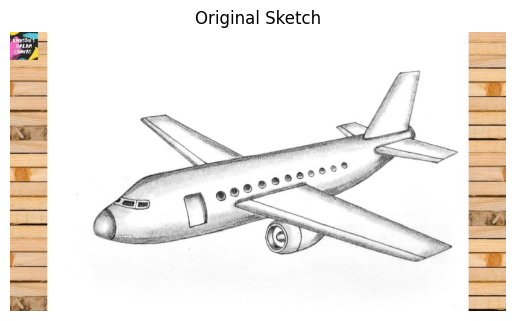

Loading caption model blip-large...
Loading CLIP model ViT-L-14/openai...


/usr/local/lib/python3.11/dist-packages/open_clip/factory.py:388: UserWarning: These pretrained weights were trained with QuickGELU activation but the model config does not have that enabled. Consider using a model config with a "-quickgelu" suffix or enable with a flag.
  warnings.warn(


Loaded CLIP model and data in 13.01 seconds.


/usr/local/lib/python3.11/dist-packages/clip_interrogator/clip_interrogator.py:200: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
  0%|          | 0/55 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/clip_interrogator/clip_interrogator.py:376: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 55/55 [00:00<00:00, 202.03it/s]
/usr/local/lib/python3.11/dist-packages/clip_interrogator/clip_interrogator.py:271: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():
Flavor chain:   0%|          | 0/32 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/clip_interrogator/clip_interrogator.py:260: FutureWarning: `torc

In [34]:
# generate prompt
sketch = Image.open("sketch5.jpg")
image_path = "sketch5.jpg"
img = Image.open(image_path)
plt.figure()
plt.imshow(img)
plt.axis('off')
plt.title("Original Sketch")
plt.show()
base_prompt = ClipInterrogator(image_path)

In [35]:
print(f"Base prompt: {base_prompt}")

Base prompt: drawing of a passenger jet airplane on a wooden surface, grey metal body, pencil illustration, gray anthropomorphic, cut-away, impossibly lifelike composition, heavy eyeliner, full subject shown in photo, travel upwards, featureless, overweight


### Generate Images


Generating with style: realistic
Enhanced prompt: drawing of a passenger jet airplane on a wooden surface,hyper realistic, 8k, ultra detailed, photographic, intricate details, professional photography, professional photography, 4k resolution, atmospheric perspective, balanced framing


  0%|          | 0/25 [00:00<?, ?it/s]

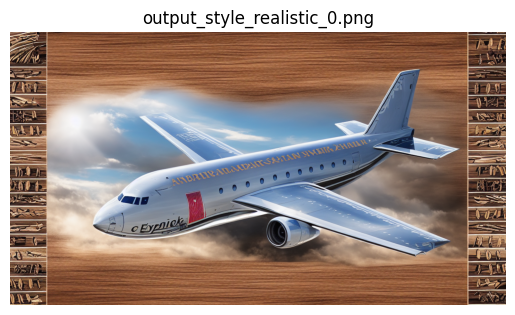


Generating with style: fantasy
Enhanced prompt: drawing of a passenger jet airplane on a wooden surface,fantasy art, dreamlike, mystical, ethereal, magical, vibrant colors, highly detailed, intricate details, ray tracing, leading lines, depth of field


  0%|          | 0/25 [00:00<?, ?it/s]

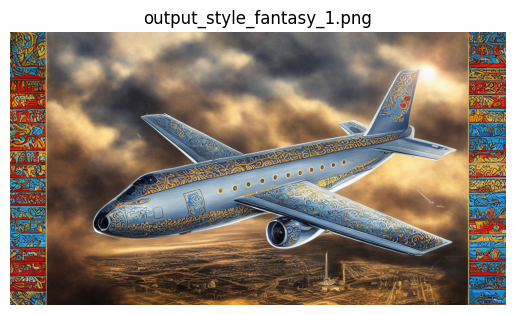


Generating with style: anime
Enhanced prompt: drawing of a passenger jet airplane on a wooden surface,anime style, vibrant colors, clean lines, expressive eyes, studio ghibli, makoto shinkai, trending on artstation, octane render, leading lines, balanced framing


  0%|          | 0/25 [00:00<?, ?it/s]

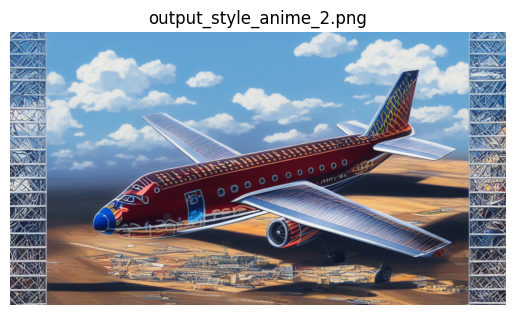

In [36]:
numStyles = 3
#generate images
for idx, style in enumerate(generator.AllStyles()[:numStyles]):
    print(f"\nGenerating with style: {style}")
    images = generator.generate(
        sketch_image=sketch,
        prompt=base_prompt,
        negative_prompt="blurry, low quality, distorted, bad anatomy, deformed",
        num_images=1,
        steps=25,
        style=style,
        enhance_prompt=True
    )
    images[0].save(f"output_style_{style}_{idx}.png")
    img = Image.open(f"output_style_{style}_{idx}.png")
    plt.figure()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"output_style_{style}_{idx}.png")
    plt.show()
